In [128]:
import warnings
warnings.filterwarnings("ignore")

# [x] Business Understanding

## [x] Objective
The goal is to classify iris flowers into one of three species (Setosa, Versicolor, Virginica) based on four features:
- Sepal length
- Sepal width
- Petal length
- Petal width

## [x] Key questions
1. Which measures play a key role in distinguishing species?
2. Which measures are important in differentiating Setosa from other 2 species?
3. Which meaasures are important in differentiating Virginica from other 2 species?
4. What are practical application of this model?
5. How well does new model improve the accuracy of our predicition?

# [x] Data Understanding

## [x]  Load data

In [87]:
from sklearn.datasets import load_iris

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
data = load_iris(
    return_X_y=False,
    as_frame=False,
)

In [90]:
X = pd.DataFrame(data['data'], columns=data['feature_names'])

In [91]:
target_map = {}
for i, name in enumerate(data['target_names']):
    target_map[i] = name

y = pd.Series(data['target'], name='species').map(target_map)

In [92]:
df = pd.concat([X, y], axis=1).sample(frac=0.8, random_state=42)


## [x]  Summary statistics

There are 4 non-null features, 120 observations

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 73 to 59
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  120 non-null    float64
 1   sepal width (cm)   120 non-null    float64
 2   petal length (cm)  120 non-null    float64
 3   petal width (cm)   120 non-null    float64
 4   species            120 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.6+ KB


In [94]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sepal length (cm),120.0,NaN,NaN,NaN,5.803333,0.830909,4.3,5.1,5.7,6.4,7.9
sepal width (cm),120.0,NaN,NaN,NaN,3.074167,0.442775,2.0,2.8,3.0,3.4,4.4
petal length (cm),120.0,NaN,NaN,NaN,3.669167,1.784894,1.0,1.5,4.2,5.1,6.9
petal width (cm),120.0,NaN,NaN,NaN,1.1725,0.777084,0.1,0.3,1.3,1.8,2.5
species,120,3,setosa,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## [x] Class distribution

In [95]:
df['species'].value_counts(normalize=True)

species
setosa        0.358333
versicolor    0.325000
virginica     0.316667
Name: proportion, dtype: float64

## [x]  Feature distribution

### [x] Feature itself 

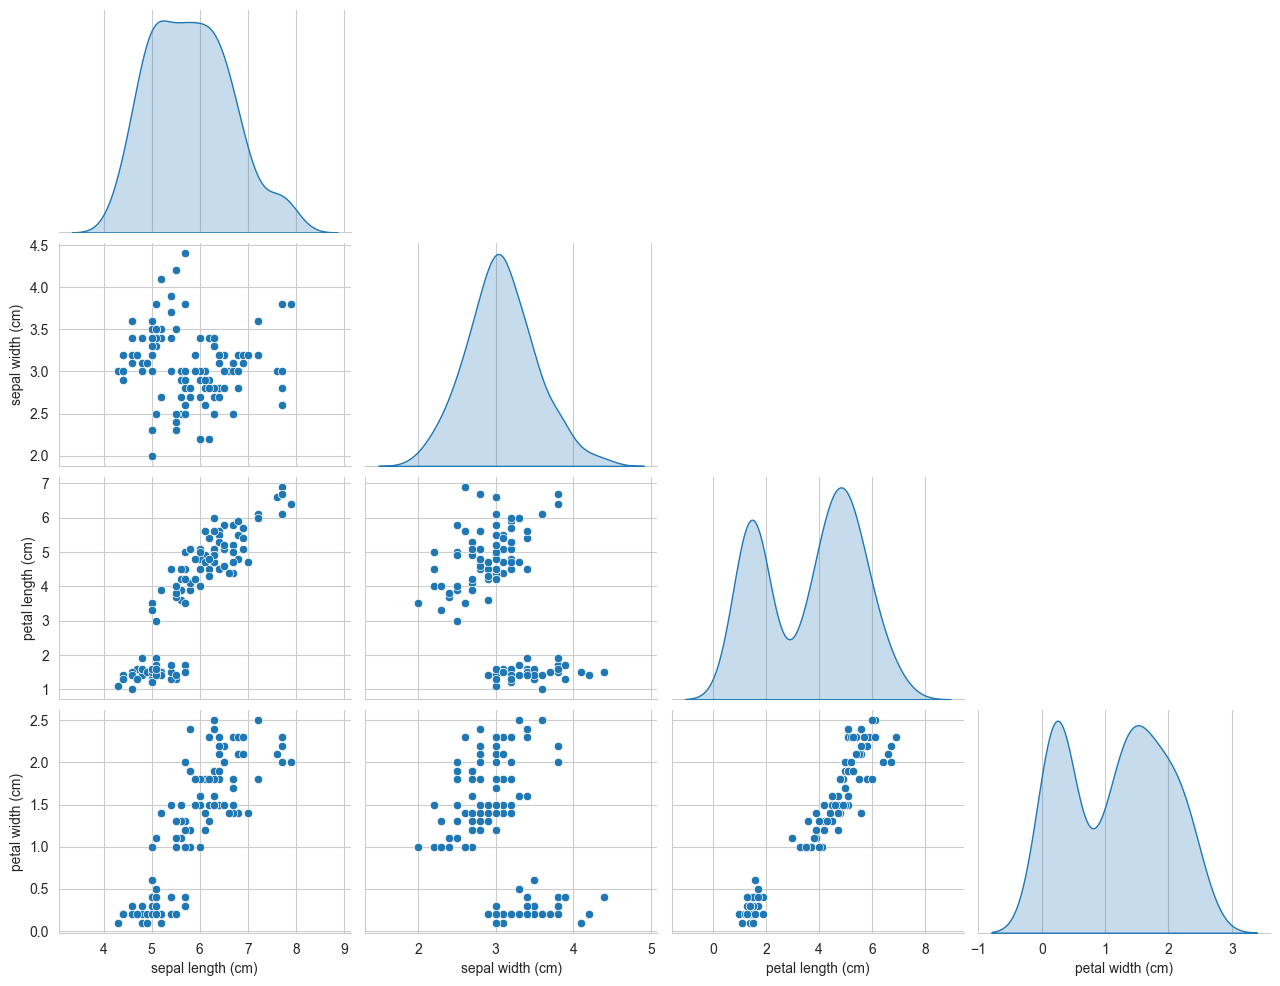

In [96]:
 sns.pairplot(
    data = df.drop('species', axis=1),
    aspect = 1.3,
    corner = True,
    diag_kind = 'kde',
)
plt.show()

### [x] Breakdown by species 

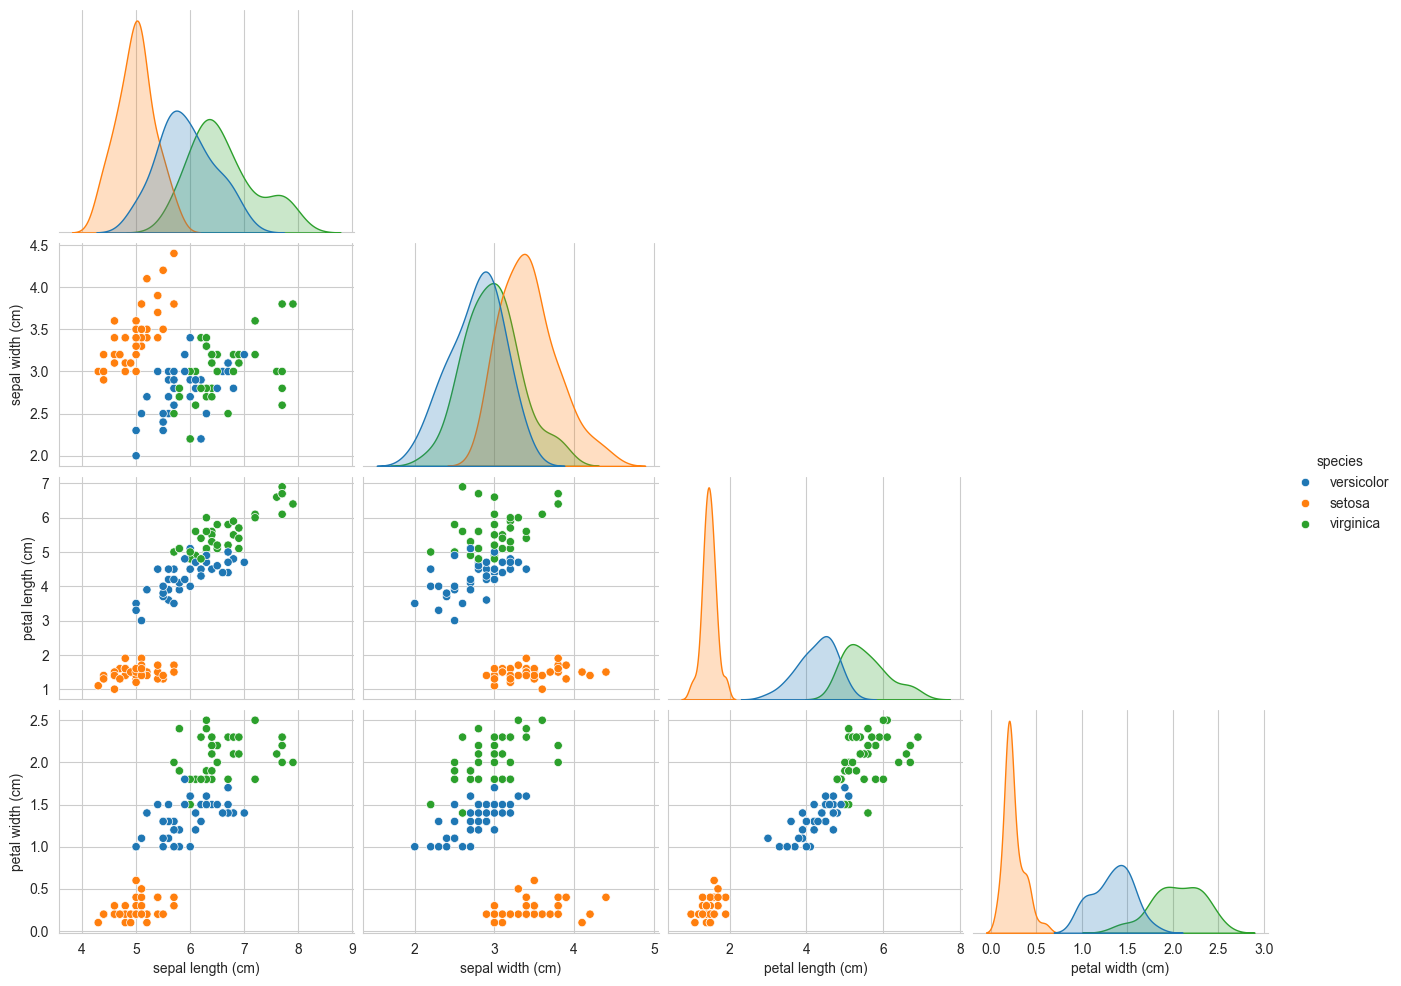

In [97]:
 sns.pairplot(
    data = df,
    hue = 'species',
    aspect = 1.3,
    corner = True
)
plt.show()

# [x] Data Preparation

## [x]  Handling Missing Values

There is no null value here, so we can skip this part

## [x]  Feature Engineering

No additional feature creation is necessary for this small dataset.

## [x]  Encoding Categorical Variables

In [98]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['species'] = label_encoder.fit_transform(df['species'])

## [x] Train-Validation-Test Split

In [171]:
from sklearn.model_selection import train_test_split

X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [172]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# [x] Modeling

## [x]  Building pipeline

In [184]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

logistic = LogisticRegression()

logistic_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

decision_tree  = DecisionTreeClassifier()

random_forest  = RandomForestClassifier()

dummy = DummyClassifier()

models = {
    'dummy': dummy,
    'logistic': logistic,
    'logistic_scaled': logistic_scaled,
    'decision_tree': decision_tree,
    'random_forest': random_forest
}

## [x] Scorers

In [174]:
scorers = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',  # Macro ensures equal weight to all classes
    'recall_macro': 'recall_macro', # Macro ensures equal weight to all classes
    'f1_macro': 'f1_macro', # Macro ensures equal weight to all classes
    'roc_auc_ovr': 'roc_auc_ovr'  # One-vs-Rest for multiclass ROC-AUC
}


## [x] Compare model combination

- LogisticRegression with StandardScaling outperformed other estimators

In [181]:
from sklearn.model_selection import cross_validate

# Perform cross-validation for all models
cv_results = {}
for name, model in models.items():
    results = cross_validate(model, X_train, y_train, cv=5, scoring=scorers, return_train_score=False)
    cv_results[name] = {metric: results[f'test_{metric}'].mean().round(2) for metric in scorers}

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df

,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_ovr
dummy,0.36,0.12,0.33,0.18,0.50
logistic,0.94,0.94,0.94,0.94,0.99
logistic_scaled,0.95,0.95,0.95,0.95,0.99
decision_tree,0.94,0.95,0.94,0.94,0.96
random_forest,0.94,0.94,0.94,0.94,0.99




# [x] Evaluation

## [x] Train optimum model 

In [178]:
selected_estimator = models['logistic_scaled']
selected_estimator.fit(X_test, y_test)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LogisticRegression())])

In [188]:
zip(selected_estimator['scaler'].get_feature_names_out(), selected_estimator['model'].coef_)

In [197]:
pd.DataFrame(
    selected_estimator['model'].coef_,
    columns=selected_estimator['scaler'].get_feature_names_out(),
    index = label_encoder.classes_
).T

,setosa,versicolor,virginica
sepal length (cm),-0.765896,0.286930,0.478966
sepal width (cm),0.898452,-0.358626,-0.539827
petal length (cm),-1.145359,-0.189129,1.334488
petal width (cm),-1.098750,-0.336908,1.435658



## [x] Re-evaluate optimum model on test data 
- Test score is close to train score indicating no overfitting here

In [180]:
res = cross_validate(
    selected_estimator,
    X_test,
    y_test,
    cv=5,
    scoring=scorers,
    return_train_score=False
)
{metric: res[f'test_{metric}'].mean().round(2) for metric in scorers}

{'accuracy': np.float64(0.94),
 'precision_macro': np.float64(0.96),
 'recall_macro': np.float64(0.93),
 'f1_macro': np.float64(0.93),
 'roc_auc_ovr': np.float64(0.99)}

# [x] Deployment

## [x] Export ready-to-production model

In [182]:
import pickle
pickle.dump(selected_estimator, open('estimator.pkl', 'wb'))

## [x] Load model to production 

In [183]:
loaded_model = pickle.load(open('estimator.pkl', 'rb'))

# [x] Answer key questions

1. **Which measures play a key role in distinguishing species?**: Sepal length, petal length, and petal width are the most useful features for classifying all three species.

2. **Which measures are important in differentiating Setosa from other 2 species?**: Setosa is clearly separated from the other species due to its small petal size.

3. **Which meaasures are important in differentiating Virginica from other 2 species**: Virginica has significant larger and longer petal compared to Setosa. Compared to Versicolor, Virginica has slightly larger and longer. Using petal length and width, Setosa << Versicolor < Virginica

4. **What are practical application of this model?**: The knowledge from this dataset can be applied to automated plant classification, agriculture research, and inventory management in nurseries, while also serving as an excellent educational tool for understanding machine learning classification techniques.

5. **How well does new model improve the accuracy of our prediction?**: Thew new model increase  accuracy from 36% to 95%, compared to random prediction (based on referenced distribution)